<style>
    span.uvk {
        font-family: sans-serif;
    }
</style>

# Tutorial: basics of notebook authoring

The following assumes that you have completed the [installation](../install)
of <span class="uvk">uvk</span> so that your Jupyter launcher shows something like the following
screenshot (perhaps with a different [display name](../reference/uvk_cli#kernel-spec-denomination)):

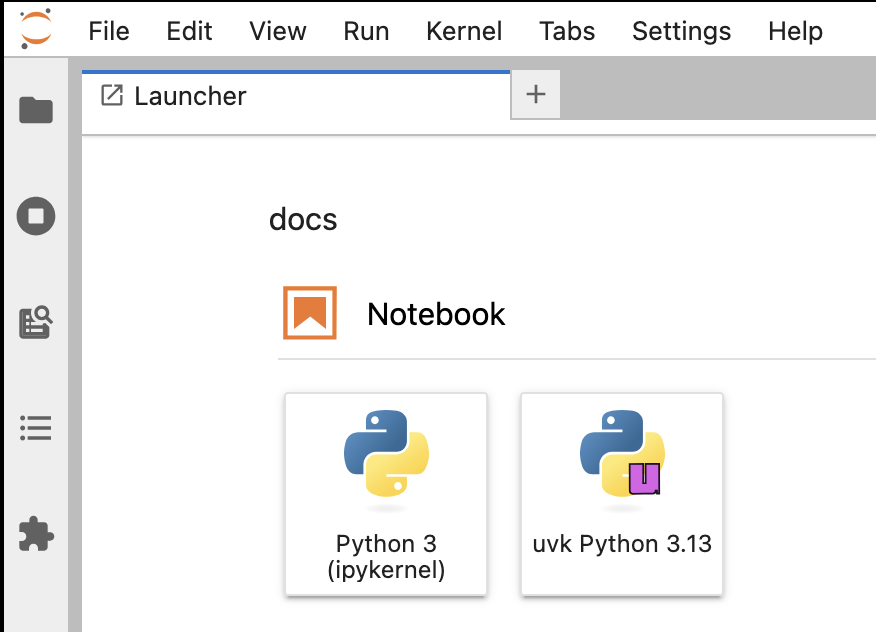


A notebook like the current tutorial ([source on Github](https://github.com/hamelin/uvk/blob/main/docs/Tutorial.ipynb)) can be created by clicking on the **uvk Python 3.xx** launcher button,
or by changing the kernel of an existing notebook (menu **Kernel** / **Change Kernel...**).
To re-run this tutorial notebook, ensure to select a <span class="uvk">uvk</span> kernel.

## Gathering external packages

First, we use the <span class="uvk">uvk</span> [extension](../reference/uvk_ext) to leverage a few nifty magics.

In [1]:
%load_ext uvk

Our tutorial requires we run at least Python 3.11.

In [2]:
%require_python >=3.11

No output means no problem!

We will visualize, using [Matplotlib](https://matplotlib.org/), a handful of random Gaussian blobs generated by [Scikit-Learn](https://scikit-learn.org/stable/).
We thus need to install these two libraries right here in our environment.
Let's first check we don't have both of them.

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

ModuleNotFoundError: No module named 'matplotlib'

Ok, we miss at least Matplotlib.
Let's gather and deploy our two required packages.

In [4]:
%%dependencies
matplotlib
scikit-learn

Resolved 15 packages in 8ms
Installed 12 packages in 79ms
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.62.1
 + joblib==1.5.3
 + kiwisolver==1.5.0
 + matplotlib==3.10.8
 + numpy==2.4.4
 + pillow==12.2.0
 + pyparsing==3.3.2
 + scikit-learn==1.8.0
 + scipy==1.17.1
 + threadpoolctl==3.6.0


Now let's try these external imports again.

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

Much better!
Let's get to work.

## Visualizing spherical blobs without distortion

In [6]:
blobs, clusters = make_blobs(n_samples=1000, centers=3)
blobs.shape

(1000, 2)

As both Matplotlib and Scikit-Learn depend on Numpy, it should be right here for us to use. Let's import it so we can check that blob labels match our request for 3 distinct blobs.

In [7]:
import numpy as np
clusters_u, counts = np.unique(clusters, return_counts=True)
np.vstack([clusters_u, counts]).T

array([[  0, 334],
       [  1, 333],
       [  2, 333]])

And now, visualize.
We will set things up so that the viewport is isotropic,
avoiding deformation of our spherical blobs from distinct horizontal and vertical spans of the dataset.

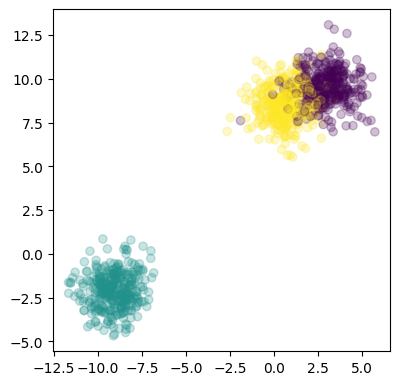

In [8]:
hmin, vmin = np.min(blobs, axis=0)
hmax, vmax = np.max(blobs, axis=0)
fig = plt.figure(figsize=.25 * np.array([hmax - hmin, vmax - vmin]))
fig.gca().scatter(x=blobs[:,0], y=blobs[:,1], c=clusters, alpha=.25)

Even unambitious goals are delightful to reach.

## A bit of curiosity

(Please allow this author some user name privacy throughout what follows.)

In [9]:
from pathlib import Path

def user2heyhey(path):
    return path.replace(str(Path.home()), "/home/heyhey")

So the [documentation](../) promises this kernel is running from an isolated environment.
Let's check.

In [10]:
import sys
sys.prefix

'/Users/hamelin/.cache/uv/builds-v0/.tmpKR6FPX'

This kernel process is presumed to have been launched using `uv`.
Let's look up the command line of the parent process.

In [11]:
%uv pip install psutil
from psutil import Process

Audited 1 package in 36ms


In [12]:
parent = Process().parent()
" ".join(user2heyhey(token) for token in parent.cmdline())

'/home/heyhey/uvk/.venv/bin/uv run --with uvk --isolated python -m ipykernel_launcher -f /home/heyhey/Library/Jupyter/runtime/kernel-7a62a715-73de-41b6-a533-f0bad53ac87f.json'

This tracks as presumed.
So if the kernel is running out of an isolated environment,
likely the `uv` executable lives in a directory outside of `sys.prefix`.

In [13]:
user2heyhey(parent.exe())

'/home/heyhey/uvk/.venv/bin/uv'

Indeed, it is running out of the project's cached venv.
This makes sense, as the author of this tutorial runs Jupyter Lab from his local copy of the <span class="uvk">uvk</span> project.
If the notebook is run from a distinct context,
it should be reflected here.

Further on,
the Python interpreter that runs the Jupyter Lab instance
(which spawned the `uv` command to start this notebook's kernel)
is likely distinct
(at least before symbolic link resolution)
from the Python interpreter known to drive this kernel.
First let's just ensure the grandparent process of the kernel is indeed a Jupyter instance.

In [14]:
" ".join(user2heyhey(token) for token in parent.parent().cmdline())

'/home/heyhey/uvk/.venv/bin/python3 /home/heyhey/uvk/.venv/bin/jupyter-lab --no-browser'

Yep! So which is this kernel's Python?

In [15]:
print(f"This kernel's Python:       {user2heyhey(sys.executable)}")
print(f"The Python running Jupyter: {parent.parent().exe()}")

This kernel's Python:       /home/heyhey/.cache/uv/builds-v0/.tmpKR6FPX/bin/python
The Python running Jupyter: /Users/hamelin/miniconda3/envs/home/bin/python3.13


If there is a difference between the path to the Python interpreter that starts the command line in the next-to-last cell and that running Jupyter,
it is because `psutil` resolves the sequence of symbolic link when invoking `.exe()` for a process.
So likely the former is a symbolic link whose resolution corresponds to the latter.
Checking is left as homework to the reader.